../logs/mnist_idle/alphaFidle-60sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-60sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-60sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-70sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-70sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-70sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-80sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-80sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-80sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/mnist_idle/alphaFidle-90sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x


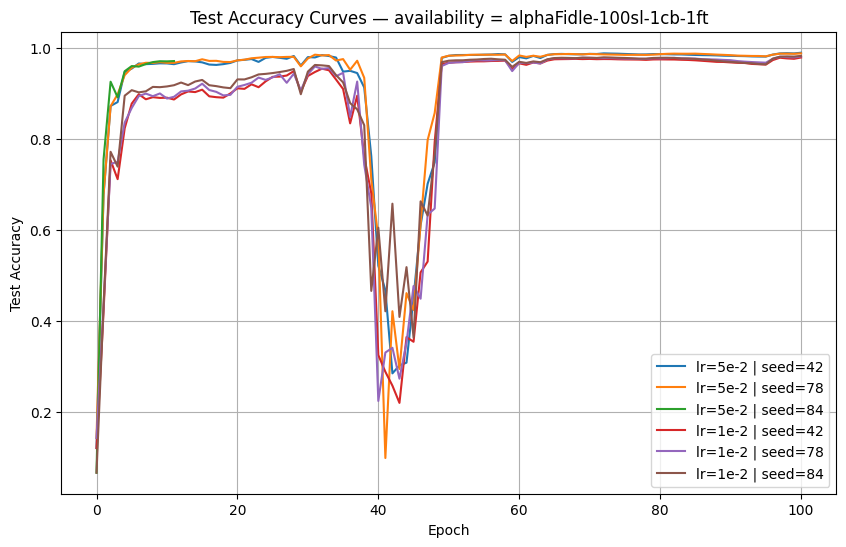

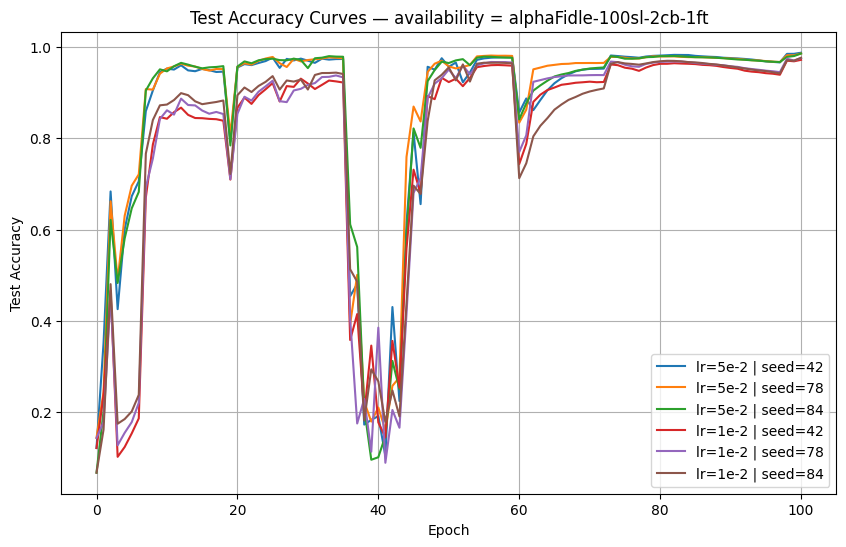

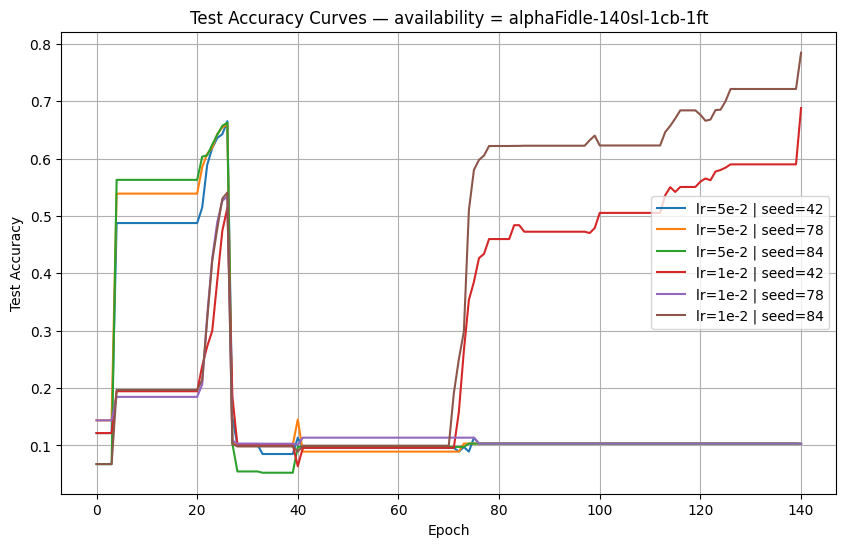

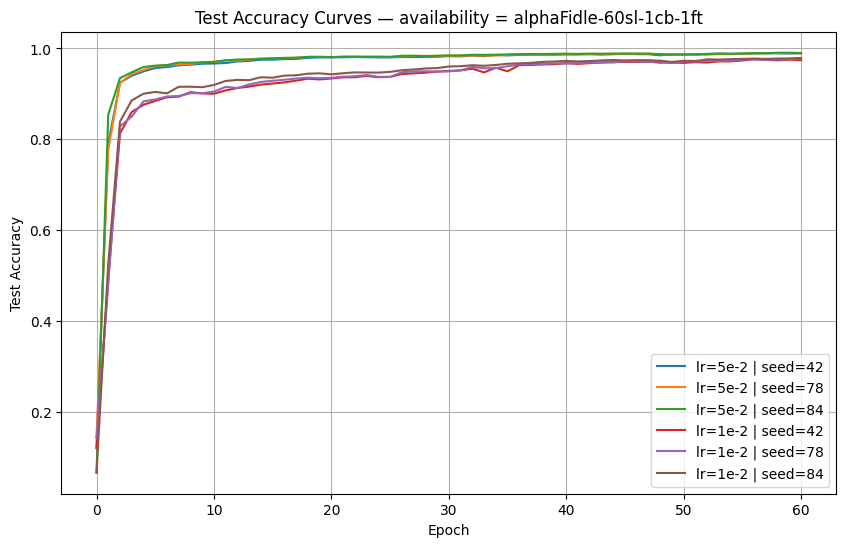

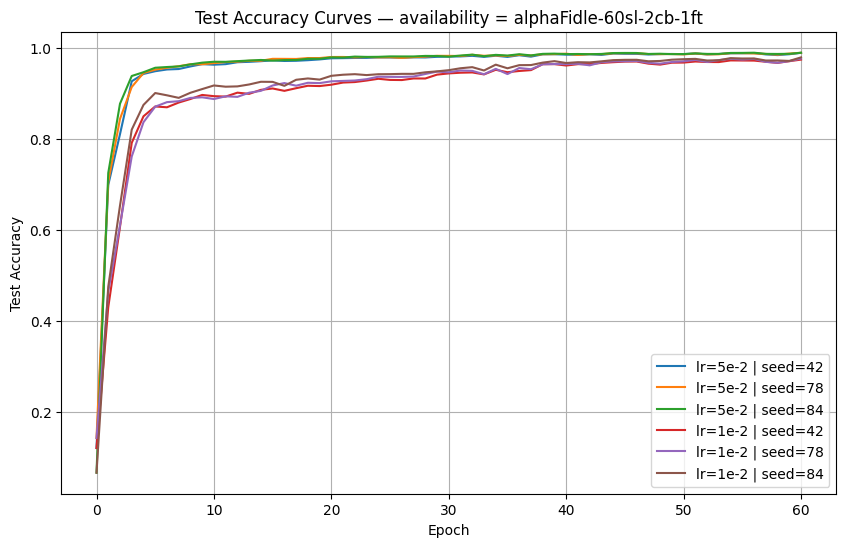

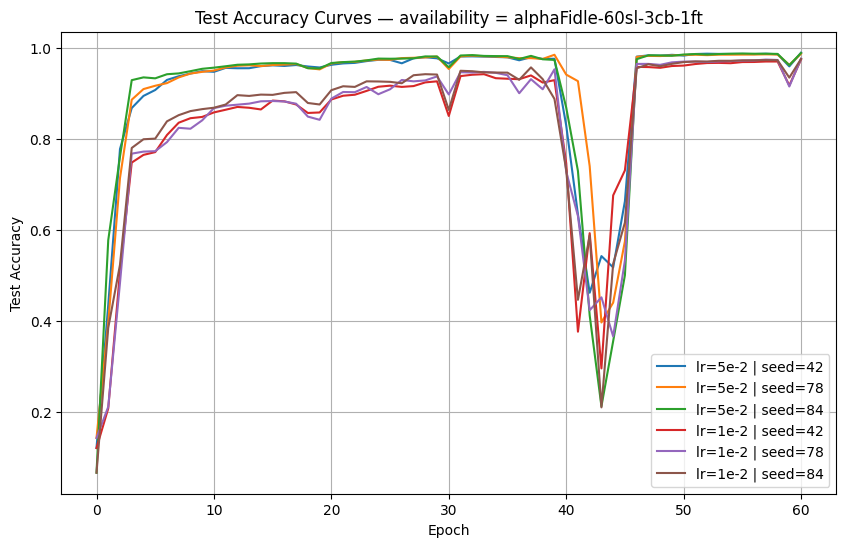

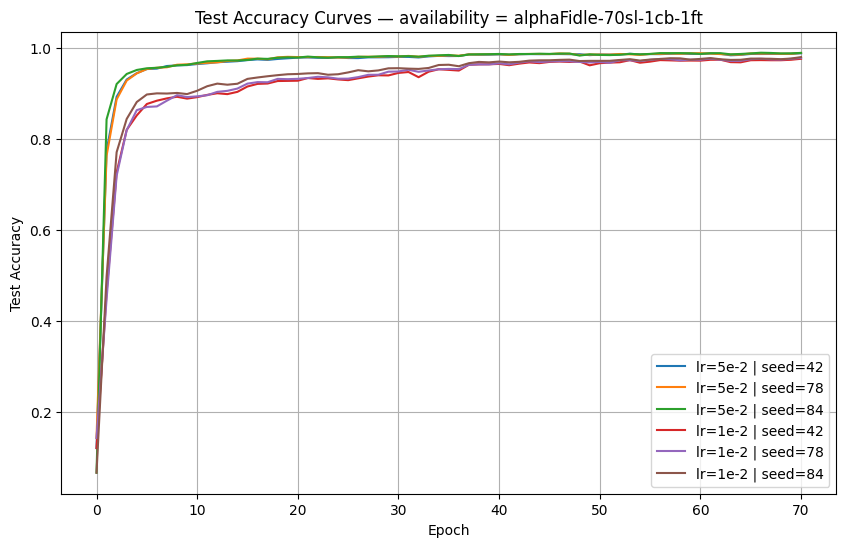

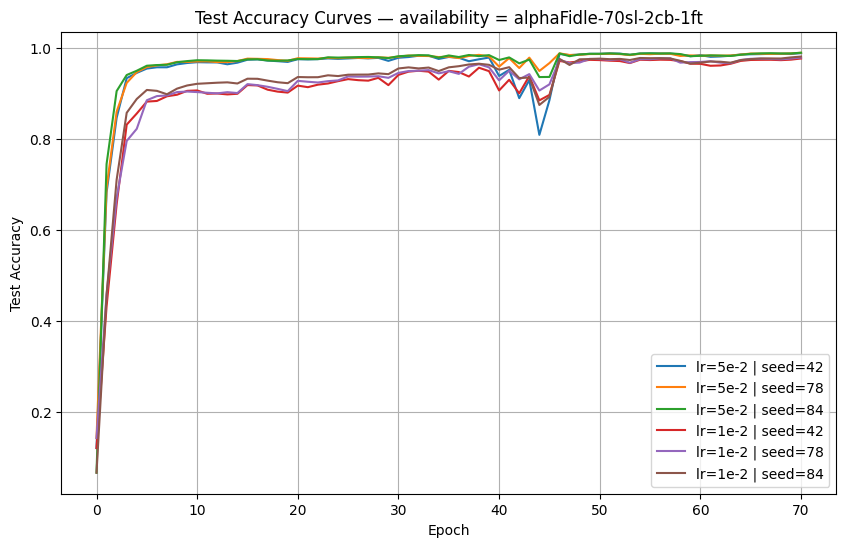

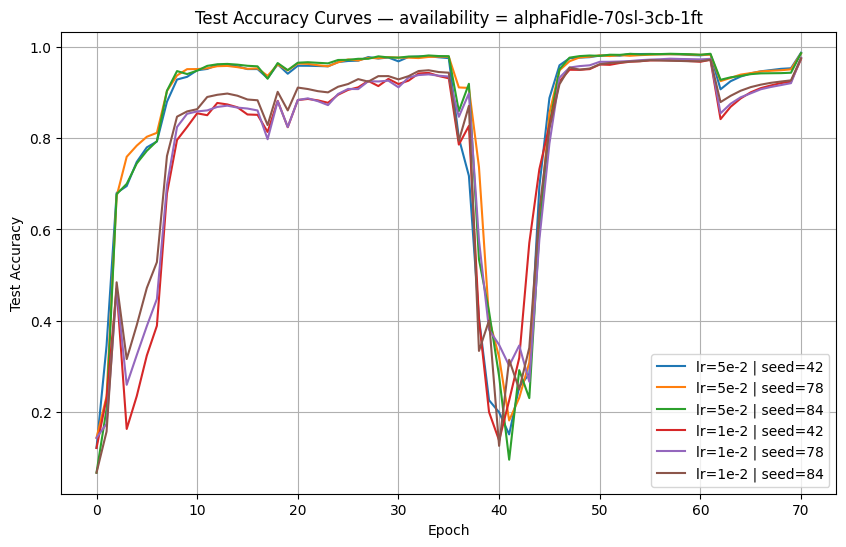

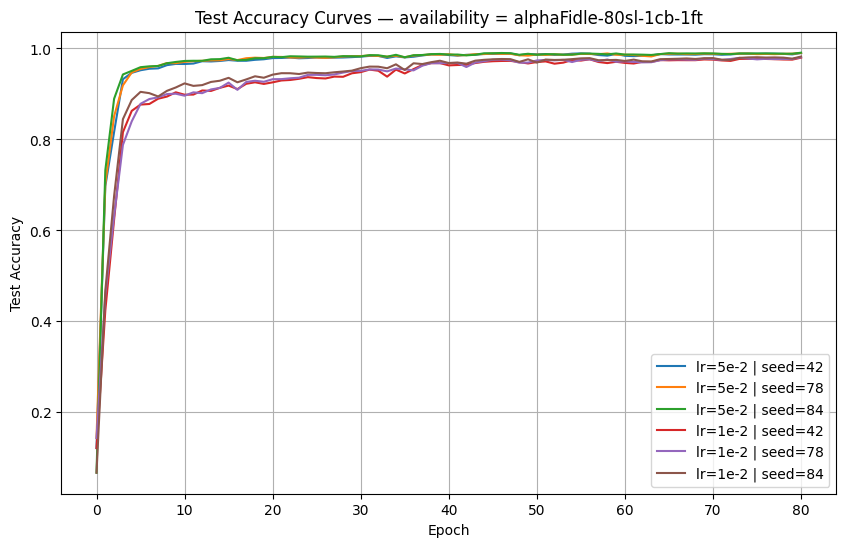

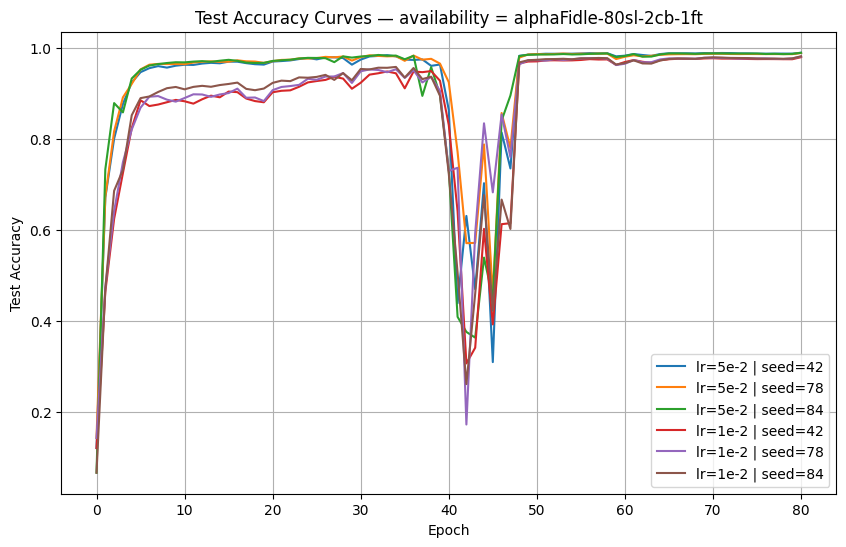

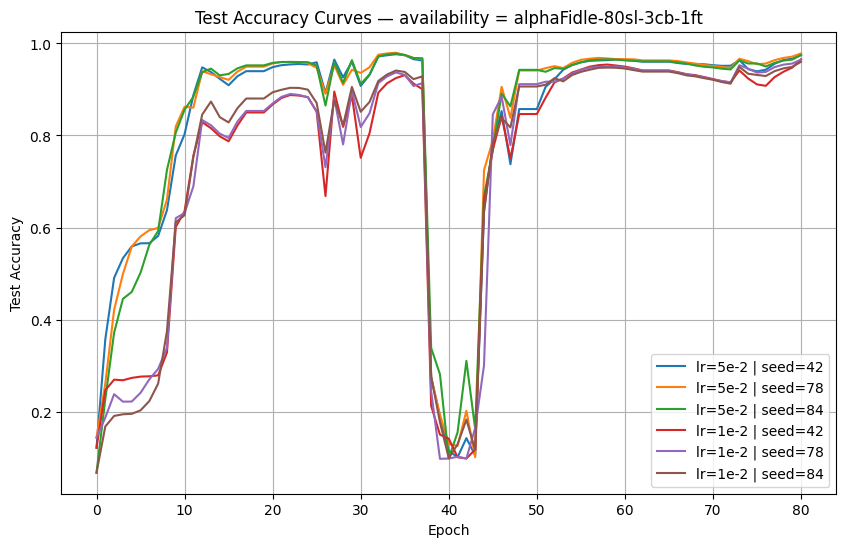

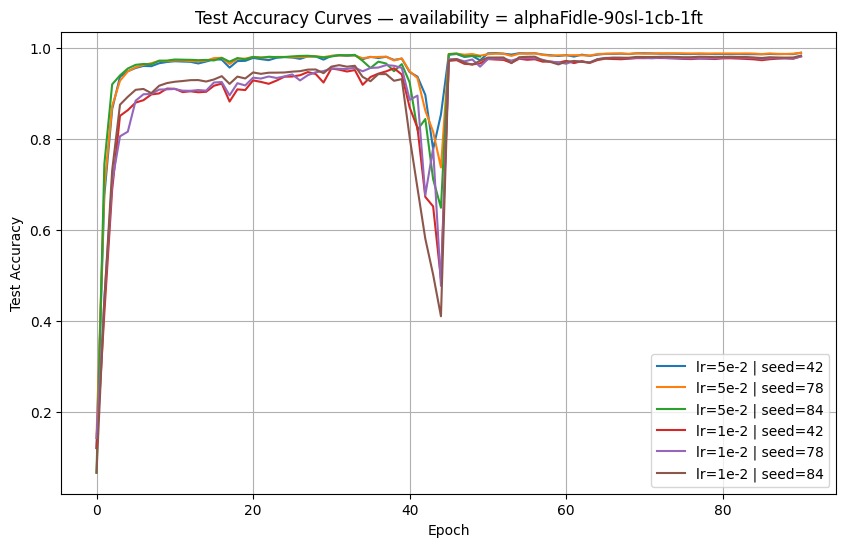

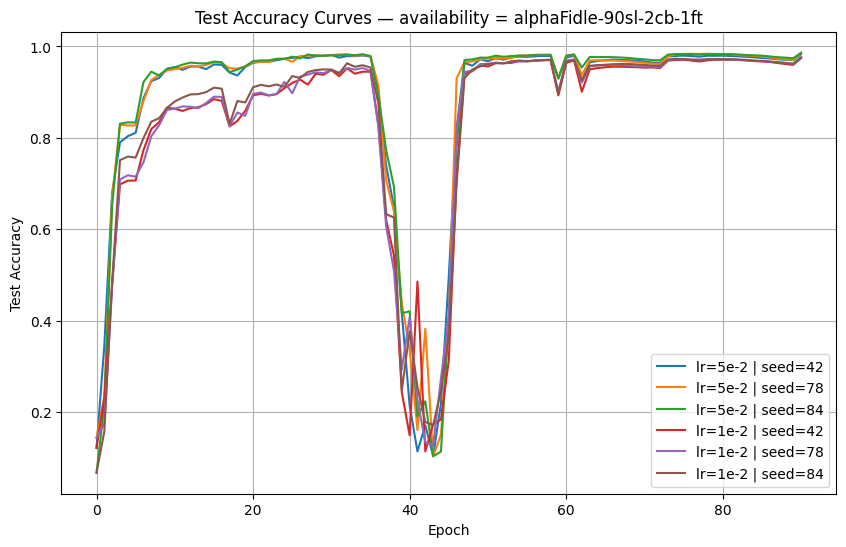

In [ ]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    # print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        print(event_dir)


                                        if os.path.exists(event_dir):
                                            print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

# main_folder = 'cifar10_accuracy_check'
# # ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

# # availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-2cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-4cb-3ft alphaF-120sl-5cb-3ft alphaF-120sl-6cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-4cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-4cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft".split()
# availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-6cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-5cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft alphaF-180sl-3cb-3ft alphaF-180sl-5cb-3ft alphaF-180sl-6cb-3ft alphaF-180sl-7cb-3ft alphaF-200sl-1cb-3ft alphaF-200sl-3cb-3ft alphaF-200sl-5cb-3ft alphaF-200sl-6cb-3ft alphaF-200sl-7cb-3ft".split() # list of availability matrices
# # availabilities="alphaF-120sl-2cb-3ft alphaF-120sl-4cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-4cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-4cb-3ft alphaF-180sl-2cb-3ft alphaF-180sl-4cb-3ft alphaF-200sl-2cb-3ft alphaF-200sl-4cb-3ft".split() # list of availability matrices

# availabilities="alphaF-120sl-1cb-1ft alphaF-120sl-2cb-1ft alphaF-120sl-3cb-1ft".split()
# availabilities="alphaF-120sl-4cb-1ft alphaF-120sl-5cb-1ft alphaF-120sl-6cb-1ft alphaF-120sl-7cb-1ft alphaF-120sl-8cb-1ft".split()
# # availabilities="alphaF-200sl-1cb-1ft alphaF-200sl-2cb-1ft alphaF-200sl-3cb-1ft alphaF-200sl-4cb-1ft alphaF-200sl-5cb-1ft alphaF-200sl-6cb-1ft alphaF-200sl-7cb-1ft alphaF-200sl-8cb-1ft".split()
# # availabilities="alphaF-140sl-1cb-1ft alphaF-140sl-2cb-1ft alphaF-140sl-3cb-1ft alphaF-140sl-4cb-1ft alphaF-140sl-5cb-1ft alphaF-140sl-6cb-1ft alphaF-140sl-7cb-1ft alphaF-140sl-8cb-1ft alphaF-160sl-1cb-1ft alphaF-160sl-2cb-1ft alphaF-160sl-3cb-1ft alphaF-160sl-4cb-1ft alphaF-160sl-5cb-1ft alphaF-160sl-6cb-1ft alphaF-160sl-7cb-1ft alphaF-160sl-8cb-1ft alphaF-180sl-1cb-1ft alphaF-180sl-2cb-1ft alphaF-180sl-3cb-1ft alphaF-180sl-4cb-1ft alphaF-180sl-5cb-1ft alphaF-180sl-6cb-1ft alphaF-180sl-7cb-1ft alphaF-180sl-8cb-1ft".split()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", "78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['1e-2'], alphas=["0.5"], n_clients_list=["7"],
#                           availabilities=availabilities,
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

main_folder = 'mnist_idle_accuracy_check'
# availabilities="""
# alphaF-60sl-5cb-1ft 
# alphaF-60sl-6cb-1ft 
# alphaF-60sl-7cb-1ft 
# alphaF-70sl-5cb-1ft 
# alphaF-70sl-6cb-1ft 
# alphaF-70sl-7cb-1ft 
# alphaF-80sl-5cb-1ft 
# alphaF-80sl-6cb-1ft 
# alphaF-80sl-7cb-1ft 
# alphaF-90sl-5cb-1ft 
# alphaF-90sl-6cb-1ft 
# alphaF-90sl-7cb-1ft 
# alphaF-100sl-5cb-1ft 
# alphaF-100sl-6cb-1ft 
# alphaF-100sl-7cb-1ft 
# alphaF-120sl-5cb-1ft 
# alphaF-120sl-6cb-1ft 
# alphaF-120sl-7cb-1ft 
# alphaF-140sl-5cb-1ft 
# alphaF-140sl-6cb-1ft 
# alphaF-140sl-7cb-1ft 
# alphaF-160sl-5cb-1ft 
# alphaF-160sl-6cb-1ft 
# alphaF-160sl-7cb-1ft 
# alphaF-180sl-5cb-1ft 
# alphaF-180sl-6cb-1ft 
# alphaF-180sl-7cb-1ft 
# alphaF-200sl-5cb-1ft 
# alphaF-200sl-6cb-1ft 
# alphaF-200sl-7cb-1ft 
# """.split()
availabilities="""alphaFidle-60sl-1cb-1ft alphaFidle-60sl-2cb-1ft alphaFidle-60sl-3cb-1ft 
alphaFidle-70sl-1cb-1ft alphaFidle-70sl-2cb-1ft alphaFidle-70sl-3cb-1ft 
alphaFidle-80sl-1cb-1ft alphaFidle-80sl-2cb-1ft alphaFidle-80sl-3cb-1ft 
alphaFidle-90sl-1cb-1ft alphaFidle-90sl-2cb-1ft 
alphaFidle-100sl-1cb-1ft alphaFidle-100sl-2cb-1ft 
alphaFidle-120sl-1cb-1ft 
alphaFidle-140sl-1cb-1ft""".split()


config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_idle", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['5e-2', '1e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = get_exp_stats(config)

results_df

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
for availability_value, group in results_df.groupby("availability"):
    
    plt.figure(figsize=(10, 6))
    
    for _, row in group.iterrows():
        label = f"lr={row['lr']} | seed={row['seed']}"
        plt.plot(row['test_accuracy'], label=label)
    
    plt.title(f"Test Accuracy Curves — availability = {availability_value}")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10", seeds=["42", '78', '84'],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2','1e-2'], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=["alphaF-0cb-3ft"],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# results_df = load_experiment_results(config)
# # plot_availability_comparison_mean_seed(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat/ft')